In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Mar 14 14:32:06 2026

@author: priya
"""

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

#file_path = 'C:/Users/priya/OneDrive/Desktop/Prof. Arnab Hazra Project/ShARE_files/ShARE_files/data_files/data_station1.csv'
df = pd.read_csv('data_station1.csv')
dt_index = pd.date_range( start="2010-01-01 00:00:00", end="2023-03-31 23:00:00", freq="H")

df['datetime'] = dt_index
df = df.set_index("datetime")
sco = df['co']
sco = sco['2019':'2023']

dco = sco.to_frame()

def df_to_x_y(df, window_size):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [[a] for a in df_as_np[i : i + 12]]
        x.append(row)
        label = df_as_np[i+12]
        y.append(label)
    return np.array(x), np.array(y)

window_size = 12
x,y = df_to_x_y(sco.dropna(), window_size)

X_train, Y_train = x[:30000], y[:30000]
X_val, Y_val = x[30000:34000], y[30000:34000]
X_test, Y_test = x[34000:], y[34000:]

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((12,1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))
print(model1.summary())



/tmp/ipykernel_1662/283415495.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt_index = pd.date_range( start="2010-01-01 00:00:00", end="2023-03-31 23:00:00", freq="H")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [2]:
cp = ModelCheckpoint('model1.keras', save_best_only = True)
model1.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.001),metrics = [RootMeanSquaredError()])
model1.fit(X_train,Y_train,validation_data = (X_val, Y_val), epochs = 10, callbacks =  [cp])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.5698 - root_mean_squared_error: 0.7548 - val_loss: 0.2229 - val_root_mean_squared_error: 0.4721
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2587 - root_mean_squared_error: 0.5086 - val_loss: 0.1896 - val_root_mean_squared_error: 0.4355
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.2538 - root_mean_squared_error: 0.5037 - val_loss: 0.1886 - val_root_mean_squared_error: 0.4343
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2489 - root_mean_squared_error: 0.4989 - val_loss: 0.1926 - val_root_mean_squared_error: 0.4388
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.2459 - root_mean_squared_error: 0.4959 - val_loss: 0.1880 - val_root_mean_squared_error: 0.4336
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2452 - root_mean_squared_error: 0.4952 - val_loss: 0.2071 - val_root_mean_squared_error: 0.4551
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/ste

In [3]:
from tensorflow.keras.models import load_model
model1 = load_model('model1.keras')


In [4]:
train_predictions = model1.predict(X_train).flatten()
train_results = pd.DataFrame(data = { 'Training Predictions': train_predictions, 'Actuals': Y_train})
train_results


938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


,Training Predictions,Actuals
0,0.958899,0.89
1,0.912156,0.89
2,0.959367,0.86
3,0.920298,0.99
4,1.110985,0.92
...,...,...
29995,0.825811,0.83
29996,0.853705,0.87
29997,0.901613,1.10
29998,1.201997,1.20


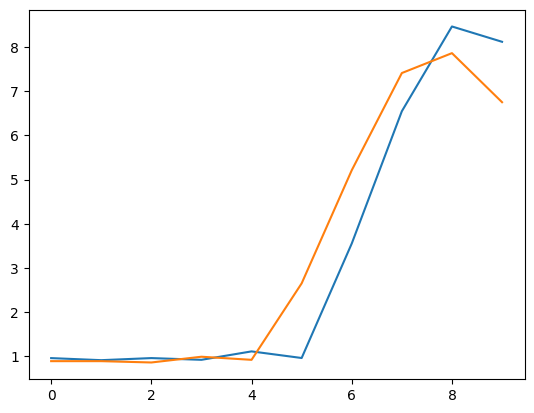

In [5]:
plt.plot(train_results['Training Predictions'][:10])
plt.plot(train_results['Actuals'][:10])

In [6]:
val_predictions = model1.predict(X_val).flatten()
val_results = pd.DataFrame(data = { 'Validation Predictions': val_predictions, 'Actuals': Y_val})
val_results

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Validation Predictions,Actuals
0,1.029273,0.95
1,0.893025,1.04
2,1.043946,1.01
3,0.979983,0.99
4,0.971984,0.95
...,...,...
3995,2.931608,2.43
3996,2.392907,2.23
3997,2.104062,1.99
3998,1.797968,1.91


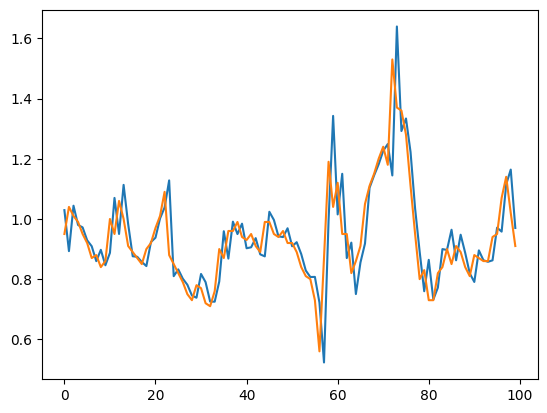

In [7]:
plt.plot(val_results['Validation Predictions'][:100])
plt.plot(val_results['Actuals'][:100])

In [8]:
test_predictions = model1.predict(X_test).flatten()
test_results = pd.DataFrame(data = { 'Test Predictions': test_predictions, 'Actuals': Y_test})
test_results

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Test Predictions,Actuals
0,1.160276,1.12
1,0.994217,1.21
2,1.228536,1.06
3,1.042767,1.08
4,1.142463,1.04
...,...,...
2179,0.776678,0.82
2180,0.844715,1.15
2181,1.254508,0.93
2182,0.840461,0.74


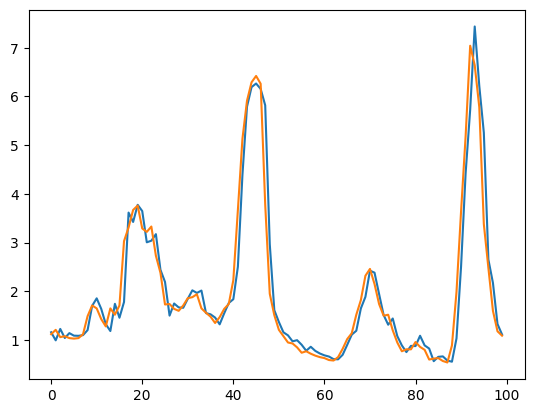

In [9]:
plt.plot(test_results['Test Predictions'][:100])
plt.plot(test_results['Actuals'][:100])

In [10]:
from sklearn.metrics import r2_score

# Ensure your predictions are flattened (which you already did for train and val)
# train_predictions = model1.predict(X_train).flatten()
# val_predictions = model1.predict(X_val).flatten()
# test_predictions = model1.predict(X_test).flatten()

r2_train = r2_score(Y_train, train_predictions)
r2_val = r2_score(Y_val, val_predictions)
r2_test = r2_score(Y_test, test_predictions)

print(f"Training R2: {r2_train:.4f}")
print(f"Validation R2: {r2_val:.4f}")
print(f"Testing R2: {r2_test:.4f}")

Training R2: 0.9130
Validation R2: 0.9345
Testing R2: 0.8902
